# Setup

In [12]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

print("Added to PYTHONPATH:", PROJECT_ROOT)

Added to PYTHONPATH: c:\Users\yfess\Desktop\timeseries-thesis


In [13]:
from dotenv import load_dotenv
import os

env_file = PROJECT_ROOT / ".env"
print(env_file.exists())
load_dotenv(env_file)
print("Loaded env file:", env_file)

True
Loaded env file: c:\Users\yfess\Desktop\timeseries-thesis\.env


In [14]:
from src.common.config import load_config
from src.common.logger import get_logger
from src.databases.benchmark_db.config import get_postgres_config
from src.databases.benchmark_db.benchmark_db import BenchmarkDB

benchmarkdb_config_file_path = PROJECT_ROOT / "configs/config-benchmarkdb.yml"
benchmarkdb_config_dict = load_config(benchmarkdb_config_file_path)

logger = get_logger("benchmark_db", benchmarkdb_config_dict["general"]["log_file"])
benchmarkdb_config = get_postgres_config(benchmarkdb_config_dict["database"])
benchmarkdb_repo = BenchmarkDB(benchmarkdb_config, logger)

try:
    benchmarkdb_repo.connect()
    print("Connected to BenchmarkDB successfully.")
except Exception as e:
    print("Failed to connect to BenchmarkDB:", e)

Connected to BenchmarkDB successfully.


# Load Results

In [15]:
read_range_ALL = benchmarkdb_repo.get_all_read_range_benchmark_results()
len(read_range_ALL)

225

In [16]:
one_r = read_range_ALL[0]
print(one_r.to_dict())

{'id': 76, 'benchmark_name': 'read.range_query', 'database_system': 'influxdb', 'database_version': '2.7', 'parameter': 'sea_water_temperature', 'range_window': '1_day', 'start_time': '2015-03-10T00:00:00+00:00', 'end_time': '2015-03-11T00:00:00+00:00', 'result_row_count': 240, 'elapsed_time_seconds': 0.1173591, 'elapsed_time_ns': 117359100, 'created_at': '2026-08-14T13:53:53.569431+00:00'}


# Partition & Colors

In [17]:
from collections import defaultdict

db_results = defaultdict(list)
for r in read_range_ALL:
    db_results[r.database_system].append(r)

db_systems = sorted(db_results.keys())
db_systems

['influxdb', 'mongodb', 'timescaledb']

In [18]:
DB_COLOR_MAP = {
    'mongodb':     '#00ED64',
    'influxdb':    '#F18F13',
    'timescaledb': '#0064FF',
    'questdb':     '#FF5733',
}
DB_COLORS = ['#00ED64', '#F18F13', '#0064FF', '#FF5733', '#A855F7', '#EC4899']

db_color = {
    db: DB_COLOR_MAP.get(db, DB_COLORS[i % len(DB_COLORS)])
    for i, db in enumerate(db_systems)
}
db_color

{'influxdb': '#F18F13', 'mongodb': '#00ED64', 'timescaledb': '#0064FF'}

# DataFrame

In [19]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

rows = []
for db in db_systems:
    for r in db_results[db]:
        rows.append({
            'database_system': db,
            'parameter': r.parameter,
            'range_window': r.range_window,
            'result_row_count': r.result_row_count,
            'elapsed_ns': r.elapsed_time_ns,
            'elapsed_ms': r.elapsed_time_ns / 1_000_000,
        })

df = pd.DataFrame(rows)
df.head()

,database_system,parameter,range_window,result_row_count,elapsed_ns,elapsed_ms
0,influxdb,sea_water_temperature,1_day,240,117359100,117.3591
1,influxdb,sea_water_temperature,1_day,240,32353100,32.3531
2,influxdb,sea_water_temperature,1_day,240,75984300,75.9843
3,influxdb,sea_water_temperature,1_week,1680,171273900,171.2739
4,influxdb,sea_water_temperature,1_week,1680,208038200,208.0382


# Order Windows Logically

In [20]:
WINDOW_ORDER = [
    "1_day", "1_week", "1_month", "1_year",
    "3_years", "5_years", "10_years", "15_years_full",
]

df['range_window'] = pd.Categorical(df['range_window'], categories=WINDOW_ORDER, ordered=True)
windows_present = [w for w in WINDOW_ORDER if w in df['range_window'].unique()]
windows_present

['1_day', '1_week', '1_month', '1_year', '3_years']

# Raw Data Points + Mean Line, per Database

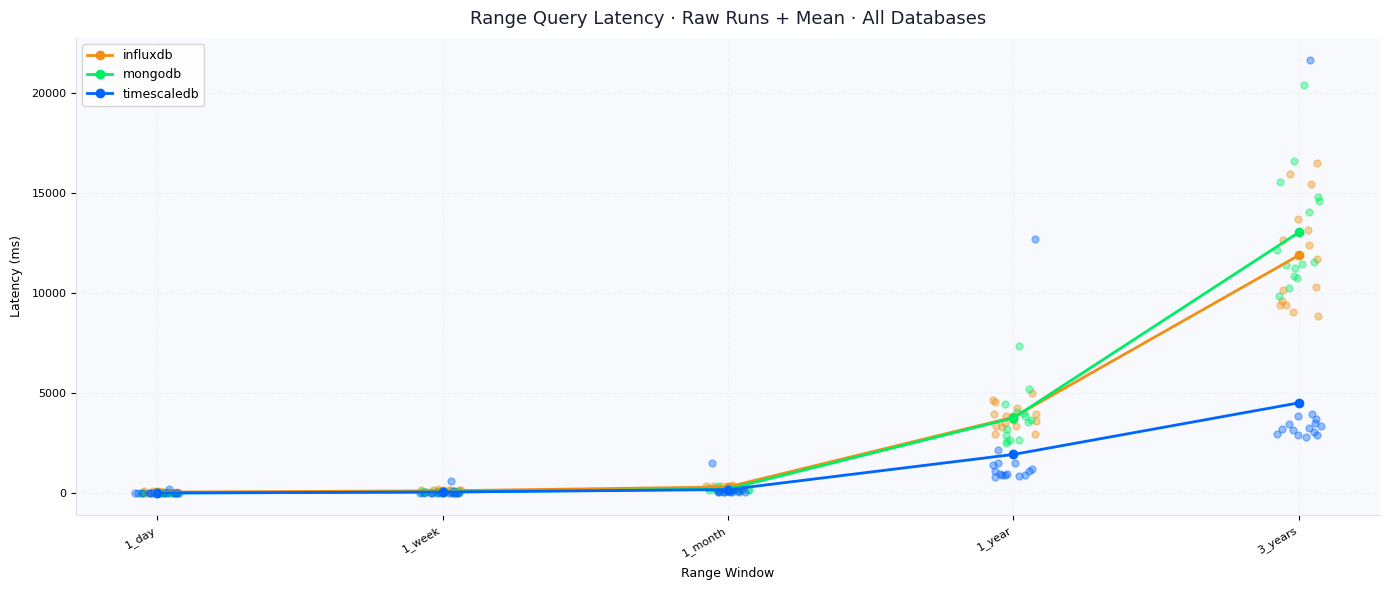

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

x_positions = {w: i for i, w in enumerate(windows_present)}

for db in db_systems:
    sub = df[df['database_system'] == db]

    # raw points, jittered slightly on x so repeats don't overlap exactly
    for w in windows_present:
        vals = sub[sub['range_window'] == w]['elapsed_ms'].values
        if len(vals) == 0:
            continue
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        xs = np.full(len(vals), x_positions[w]) + jitter
        ax.scatter(xs, vals, color=db_color[db], alpha=0.4, s=25, zorder=2)

    # mean line
    means = [
        sub[sub['range_window'] == w]['elapsed_ms'].mean() if w in sub['range_window'].values else np.nan
        for w in windows_present
    ]
    ax.plot(range(len(windows_present)), means, marker='o', color=db_color[db], linewidth=2, label=db, zorder=3)

ax.set_xticks(range(len(windows_present)))
ax.set_xticklabels(windows_present, rotation=30, ha='right', fontsize=8)
ax.set_xlabel('Range Window', fontsize=9, labelpad=6)
ax.set_ylabel('Latency (ms)', fontsize=9, labelpad=6)
ax.set_title('Range Query Latency · Raw Runs + Mean · All Databases', fontsize=13, pad=10, color='#1a1d2e')
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Log-scale version

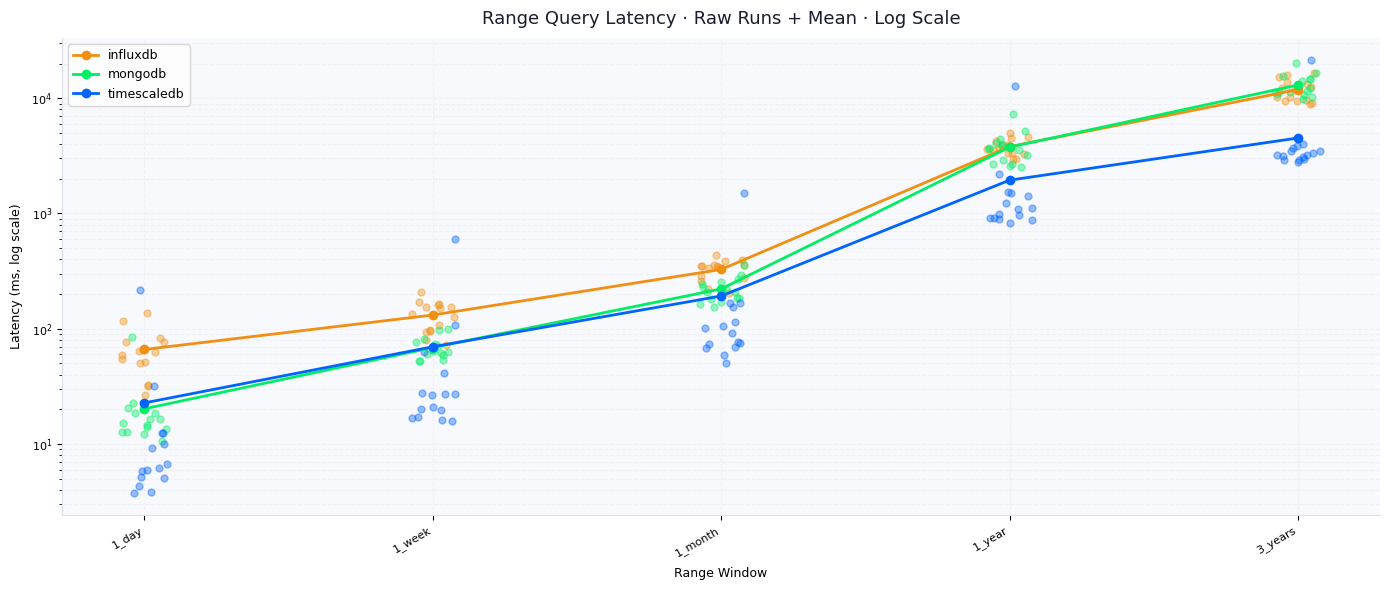

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

for db in db_systems:
    sub = df[df['database_system'] == db]

    for w in windows_present:
        vals = sub[sub['range_window'] == w]['elapsed_ms'].values
        if len(vals) == 0:
            continue
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        xs = np.full(len(vals), x_positions[w]) + jitter
        ax.scatter(xs, vals, color=db_color[db], alpha=0.4, s=25, zorder=2)

    means = [
        sub[sub['range_window'] == w]['elapsed_ms'].mean() if w in sub['range_window'].values else np.nan
        for w in windows_present
    ]
    ax.plot(range(len(windows_present)), means, marker='o', color=db_color[db], linewidth=2, label=db, zorder=3)

ax.set_yscale('log')
ax.set_xticks(range(len(windows_present)))
ax.set_xticklabels(windows_present, rotation=30, ha='right', fontsize=8)
ax.set_xlabel('Range Window', fontsize=9, labelpad=6)
ax.set_ylabel('Latency (ms, log scale)', fontsize=9, labelpad=6)
ax.set_title('Range Query Latency · Raw Runs + Mean · Log Scale', fontsize=13, pad=10, color='#1a1d2e')
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, which='both', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()